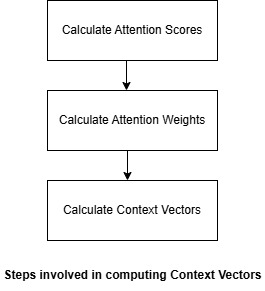

### Consider the following sentence 

#####  "Your journey starts with one step"

### Let us assume that the (raw) embeddings of each word of the sentence are as follows

In [7]:
import torch

inputs = torch.tensor([
    [0.43,0.15,0.89], #Your-> x[0]
    [0.55,0.87,0.66], #journey-> x[1]
    [0.57,0.85,0.64], #starts-> x[2]
    [0.22,0.58,0.33], #with-> x[3]
    [0.77,0.25,0.10], #one-> x[4]
    [0.05,0.80,0.55] #step-> x[5]
    
])

In [4]:
inputs.shape[0]

6

### Calculating context vector for word at index 1, i.e."journey"

In [6]:
query = inputs[1]

In [ ]:
#### Step 1: Calculate Attention Scores

In [9]:
#Calculating context vector for 
query = inputs[1]
attn_scores = torch.empty(inputs.shape[0]) #number of attention scores should be equal to number of words in the sentence
for i,x_i in enumerate(inputs):
    attn_scores[i] = torch.dot(query,x_i)

print(f"Attention Scores corresponding to x[1]: {attn_scores}")


Attention Scores corresponding to x[1]: tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [14]:
attn_scores.shape #6 rows, 1 column

torch.Size([6])

In [10]:
# Calculating Attention Weights -> Normalized Attention Scores

In [16]:
torch.sum(attn_scores,dim=0) #-> dim=0, collapsing the row dimension ; #dim=1, collapsing the column dimension

tensor(6.5617)

In [17]:
attn_scores_2_tmp = attn_scores/torch.sum(attn_scores,dim=0) 
print(attn_scores_2_tmp)

tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])


In [19]:
#Checking if the attn_scores have been normalized

torch.sum(attn_scores_2_tmp,dim=0) #Sum = 1, means the scores have indeed been normalized!!!

tensor(1.0000)

In [20]:
# Voilaaaa !!!

#### For normalization we prefer softmax function instead..

### Implementing softmax

In [23]:
#Intiazing a random tensor of dimensions (4,1)

example = torch.randn(4)
example

tensor([ 0.3707,  0.3013, -0.3789,  0.9384])

In [24]:
torch.sum(example,dim=0)

tensor(1.2315)

In [29]:
torch.exp(example)

tensor([1.4487, 1.3517, 0.6846, 2.5559])

In [31]:
#Calculating the exponentiation of each element in the tensor

exp_example = torch.exp(example)


In [35]:
total= 0.0
for i,x_i in enumerate(example):
    total+= torch.exp(x_i)

In [36]:
example_softmaxed = exp_example/total
example_softmaxed

tensor([0.2398, 0.2238, 0.1133, 0.4231])

In [38]:
#Calculating row-wise sum to see if the tensor has been normalized
torch.sum(example_softmaxed,dim=0) 

tensor(1.)

In [39]:
#However there is an inbuilt softmax fuction to implement softmax

In [41]:
torch.softmax(example,dim=0)

tensor([0.2398, 0.2238, 0.1133, 0.4231])

### ...now calculating the attention weights for x[1]

In [42]:
attn_weights_2 = torch.softmax(attn_scores,dim=0)
print(f"Attention Weights wrt Token: x[1] {attn_weights_2}")

Attention Weights wrt Token: x[1] tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])


In [43]:
torch.sum(attn_weights_2,dim=0)

tensor(1.)

### Calculating Context Vectors

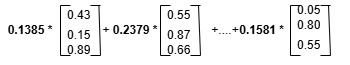

In [47]:
context_vector_2 = torch.zeros(inputs.shape[1])
for i,x_i in enumerate(inputs):
    context_vector_2+=attn_weights_2[i] * x_i

In [48]:
print(f"Context Vector 2: {context_vector_2}")

Context Vector 2: tensor([0.4419, 0.6515, 0.5683])


In [49]:
#### Now we know context vector for token x[1] 

## Calculating Context vectors for all words using Matrix operations

In [50]:
#Attention Scores

attn_scores = torch.zeros(inputs.shape[0],inputs.shape[0])
attn_scores = inputs @ inputs.T

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [56]:
#Attention Weights
attn_weights = torch.zeros(attn_scores.shape)

attn_weights = torch.softmax(attn_scores,dim=1)
                            
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [57]:
torch.sum(attn_weights,dim=1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [58]:
### Context Vectors for each word

In [ ]:
#Picture it as mupltiplying two matrices using row picture

In [59]:
context_vectors = attn_weights @ inputs

In [60]:
print(f"Final Context Vectors: {context_vectors}")

Final Context Vectors: tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])
